<a href="https://colab.research.google.com/github/Cairo-Henrique/BQC-Quantum-Tech/blob/main/BQC_Listas_Exercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit-aer pylatexenc qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=43a33fb061ea729a960b8cbd1d43afd444cd3155e6cfa8c59d17f33f2b1c0a92
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178

# Lista 1 - Bloco 1

Questão 3

In [ ]:
import numpy as np

In [ ]:
def eh_porta(porta: np.ndarray) -> bool:
    try:
        matriz_inversa = np.linalg.inv(porta.copy())
        matriz_adjunta = np.conjugate(porta.copy()).T
        return np.allclose(matriz_inversa, matriz_adjunta)
    except Exception as e:
        return False
    return False

In [ ]:
# Teste
porta = np.array([[  1,  1],
                  [  1, -1]]) / np.sqrt(2)
print(eh_porta(porta))

True


Questão 5

In [ ]:
import numpy as np

In [ ]:
def decodificar(bell: int, b1: bool, b2: bool) -> np.ndarray:
    X = np.array([[0, 1],
                  [1, 0]])
    Z = np.array([[1,  0],
                  [0, -1]])
    porta = np.eye(2)

    # Atribuir bits int
    b1 = 1 if b1 else 0
    b2 = 1 if b2 else 0

    if bell == 0: # |phi+>
        if b2 == 1:
            porta = X
        if b1 == 1:
            porta = Z @ porta

    elif bell == 1: # |psi+>
        if b1 == 0 and b2 == 0:
            porta = X
        elif b1 == 1 and b2 == 0:
            porta = Z @ X
        elif b1 == 1 and b2 == 1:
            porta = Z

    elif bell == 2: # |phi->
        if b1 == 0 and b2 == 0:
            porta = Z
        elif b1 == 0 and b2 == 1:
            porta = X @ Z
        elif b1 == 1 and b2 == 1:
            porta = X #* -1

    elif bell == 3: # |psi->
        if b1 == 0 and b2 == 0:
            porta = Z @ X
        elif b1 == 0 and b2 == 1:
            porta = Z #* -1
        elif b1 == 1 and b2 == 0:
            porta = X
        elif b1 == 1 and b2 == 1:
            porta = porta #* -1
    return porta

In [ ]:
# Teste
bells = ['|phi+>', '|psi+>', '|phi->', '|psi->']
for bell in range(4):
    print(f"Bell: {bells[bell]}")
    for b1 in [False, True]:
        for b2 in [False, True]:
            print(f"Bits: {1 if b1 else 0}{1 if b2 else 0}")
            print(decodificar(bell, b1, b2))

Bell: |phi+>
Bits: 00
[[1. 0.]
 [0. 1.]]
Bits: 01
[[0 1]
 [1 0]]
Bits: 10
[[ 1.  0.]
 [ 0. -1.]]
Bits: 11
[[ 0  1]
 [-1  0]]
Bell: |psi+>
Bits: 00
[[0 1]
 [1 0]]
Bits: 01
[[1. 0.]
 [0. 1.]]
Bits: 10
[[ 0  1]
 [-1  0]]
Bits: 11
[[ 1  0]
 [ 0 -1]]
Bell: |phi->
Bits: 00
[[ 1  0]
 [ 0 -1]]
Bits: 01
[[ 0 -1]
 [ 1  0]]
Bits: 10
[[1. 0.]
 [0. 1.]]
Bits: 11
[[0 1]
 [1 0]]
Bell: |psi->
Bits: 00
[[ 0  1]
 [-1  0]]
Bits: 01
[[ 1  0]
 [ 0 -1]]
Bits: 10
[[0 1]
 [1 0]]
Bits: 11
[[1. 0.]
 [0. 1.]]


Questão 7

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit_aer import AerSimulator

In [ ]:
def qual_porta_duas_iteracoes(porta) -> int: # 0: I, 1: X, 2: Y, 3: Z
    qr = QuantumRegister(2)
    cr = ClassicalRegister(2, name="bits")
    qc = QuantumCircuit(qr, cr)
    porta(qc, 0)
    qc.h(1)
    porta(qc, 1)
    qc.h(1)
    qc.measure([0, 1], [0, 1])
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend)
    isa_qc = pm.run(qc)
    sampler = Sampler(backend)
    job = sampler.run([isa_qc], shots=100)
    result = job.result()[0]
    counts = result.data["bits"].get_counts()
    if '00' in counts.keys():
        return 0 # I
    elif '01' in counts.keys():
        return 1 # X
    elif '10' in counts.keys():
        return 3 # Z
    return 2 # Y

In [ ]:
def qual_porta(porta) -> int:
    qr = QuantumRegister(2)
    cr = ClassicalRegister(2, name="bits")
    qc = QuantumCircuit(qr, cr)

    # Preparar um par de Bell |phi+>
    qc.h(0)
    qc.cx(0, 1)

    # Aplicar porta misteriosa
    porta(qc, 0)

    # Decodificar par único
    qc.cx(0, 1)
    qc.h(0)

    qc.measure([0,1], [0,1])
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend)
    isa_qc = pm.run(qc)
    sampler = Sampler(backend)
    job = sampler.run([isa_qc], shots=10)
    result = job.result()[0]
    counts = result.data["bits"].get_counts()

    if '00' in counts:
        return 0 # I
    elif '01' in counts:
        return 3 # Z
    elif '10' in counts:
        return 1 # X
    return 2 # Y

In [ ]:
def porta(qc, qubit):
    qc.id(qubit)

In [ ]:
qual_porta(porta)

0

# Lista 2 - Bloco 2

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

Questão 1

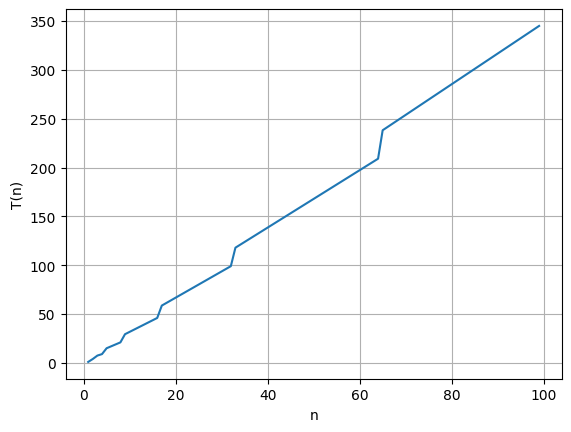

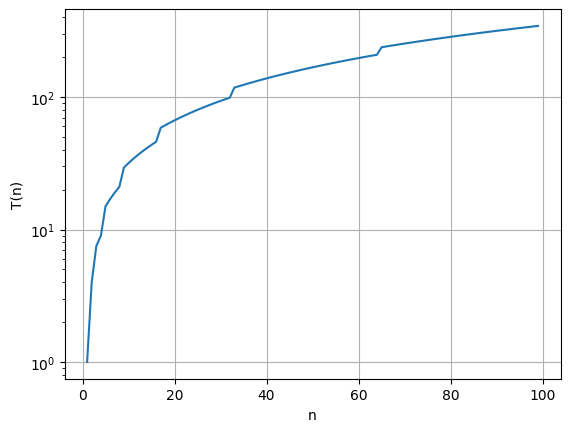

In [ ]:
def T(n):
  if n > 1:
    return T(n/2) + T(n/4) + n
  else:
    return 1

plt.figure()
plt.plot(range(1, 100), [T(n) for n in range(1, 100)])
plt.grid()
plt.xlabel('n')
plt.ylabel('T(n)')
plt.show()

plt.figure()
plt.plot(range(1, 100), [T(n) for n in range(1, 100)])
plt.grid()
plt.yscale('log')
plt.xlabel('n')
plt.ylabel('T(n)')
plt.show()

T(n) é O(n)

Questão 2

In [ ]:
def phase_oracle():
    # oráculo de fase
    qc.z(1)
    qc.z(0)
    return None

In [ ]:
from IPython.display import display

## 00
qr = QuantumRegister(3)
cr = ClassicalRegister(3, name="bits")
qc = QuantumCircuit(qr, cr)

qc.x(2)
qc.h(2)

phase_oracle()

print('f(00) = 0:')
display(Statevector.from_instruction(qc).draw('latex'))
##

## 01
qr = QuantumRegister(3)
cr = ClassicalRegister(3, name="bits")
qc = QuantumCircuit(qr, cr)

qc.x(1)

qc.x(2)
qc.h(2)

phase_oracle()


print('f(01) = 1:')
display(Statevector.from_instruction(qc).draw('latex'))
##

## 10
qr = QuantumRegister(3)
cr = ClassicalRegister(3, name="bits")
qc = QuantumCircuit(qr, cr)

qc.x(0)

qc.x(2)
qc.h(2)

phase_oracle()


print('f(10) = 1:')
display(Statevector.from_instruction(qc).draw('latex'))
##

## 11
qr = QuantumRegister(3)
cr = ClassicalRegister(3, name="bits")
qc = QuantumCircuit(qr, cr)

qc.x(0)
qc.x(1)

qc.x(2)
qc.h(2)

phase_oracle()


print('f(11) = 0:')
display(Statevector.from_instruction(qc).draw('latex'))
##

f(00) = 0:


<IPython.core.display.Latex object>

f(01) = 1:


<IPython.core.display.Latex object>

f(10) = 1:


<IPython.core.display.Latex object>

f(11) = 0:


<IPython.core.display.Latex object>

Como o sinal do |-> só inverteu onde f(x) = 1, esse é o oráculo que precisamos.

Questão 3

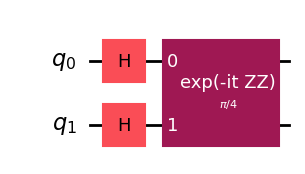

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


<IPython.core.display.Latex object>

In [ ]:
theta = np.pi/2
def U(theta, qc, qubits):
    # Define o observável ZZ
    ZZ = SparsePauliOp("ZZ")
    # Cria a porta de evolução: exp(-i * time * H)
    evo_gate = PauliEvolutionGate(ZZ, time=theta/2)
    # Aplica a porta ao qubit correspondente no circuito
    qc.append(evo_gate, qubits)

qc = QuantumCircuit(2)
qc.h([0,1])
U(theta, qc, [0, 1])
display(qc.draw('mpl'))
display(Statevector.from_instruction(qc).draw('latex'))

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


<IPython.core.display.Latex object>

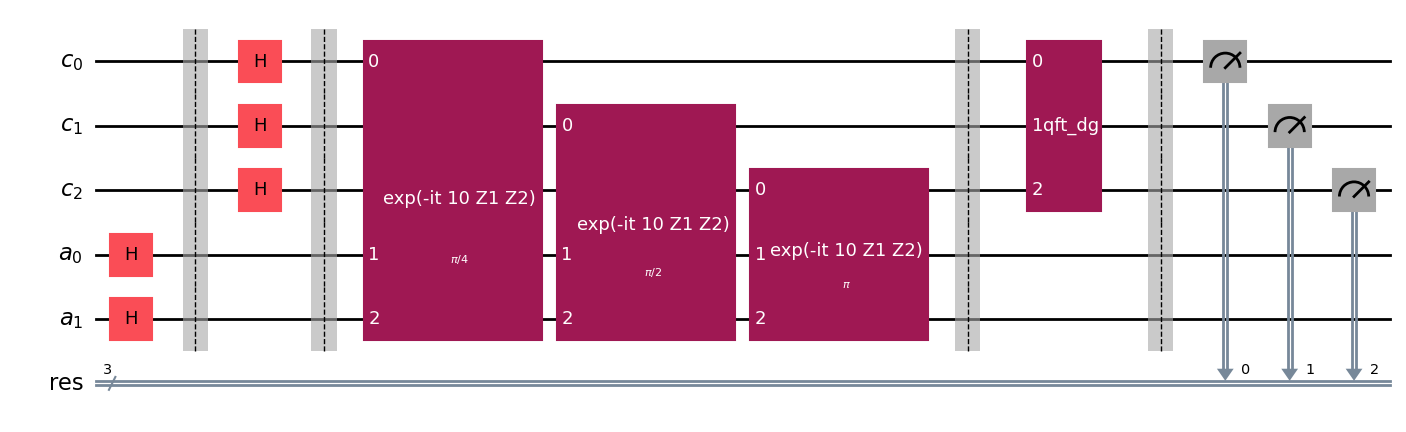

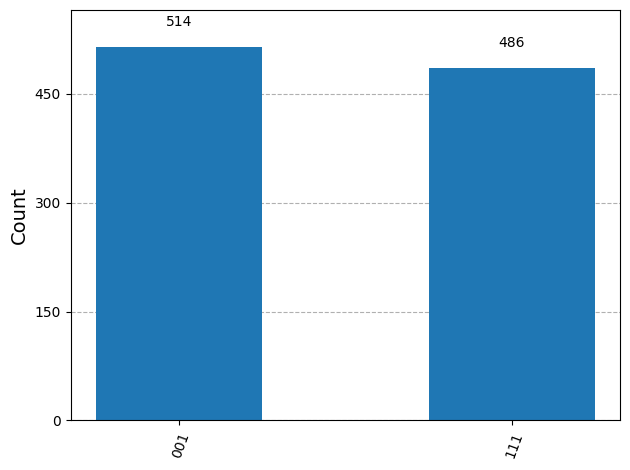

In [ ]:
# ==========================================================
# 1. CONFIGURAÇÕES
# ==========================================================
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

n_contagem = 3    # Qubits para precisão da fase
n_alvo = 2        # Qubits para o autovetor do operador U
fase_real = -1/8   # A fase que queremos estimar

# ==========================================================
# 2. OPERADORES (QFT INVERSA)
# ==========================================================
from qiskit.circuit.library import QFTGate
# Define a porta QFT Inversa
qft_inversa = QFTGate(num_qubits=n_contagem).inverse()

# ==========================================================
# 3. ALGORITMO EFQ
# ==========================================================
qr_c = QuantumRegister(n_contagem, 'c') # Registro de contagem
qr_a = QuantumRegister(n_alvo, 'a')     # Registro alvo
cr = ClassicalRegister(n_contagem, 'res')
qc = QuantumCircuit(qr_c, qr_a, cr)

# A) Preparação do Autovetor (Estado |1>)
# Para estimar a fase de uma porta P, o alvo deve estar em |1>
qc.h(qr_a)
qc.barrier()

# B) Superposição no registro de contagem
qc.h(qr_c)
qc.barrier()

# C) Aplicação das Portas Controladas Unitárias (CU^(2^j))
operador_zz = SparsePauliOp("ZZ")
theta = np.pi / 2

for i in range(n_contagem):
    # No QPE, aplicamos U^(2^i). Para uma evolução temporal,
    # isso equivale a multiplicar o tempo por 2^i.
    # Como U = exp(-i * (theta/2) * ZZ), o tempo base é theta/2.
    tempo_evolucao = (theta / 2) * (2**i)

    # Cria a porta de evolução
    evo_gate = PauliEvolutionGate(operador_zz, time=tempo_evolucao)

    # Transforma em uma porta controlada (1 qubit de controle)
    cevo_gate = evo_gate.control(1)

    # Aplica no circuito:
    # O primeiro argumento da lista é o qubit de controle (qr_c[i])
    # Os próximos são os alvos da evolução ZZ (qr_a[0] e qr_a[1])
    qc.append(cevo_gate, [qr_c[i], qr_a[0], qr_a[1]])

qc.barrier()

# D) Aplicação da QFT Inversa
qc.append(qft_inversa, qr_c)
qc.barrier()

display(Statevector.from_instruction(qc).draw('latex'))

# E) Medição
qc.measure(qr_c, cr)

# Opcional) Mostrar o circuito
display(qc.draw('mpl'))
#Mostra o circuito com o operador exposto
#display(qc.decompose(reps=1).draw('mpl'))

# ==========================================================
# 3. EXECUÇÃO
# ==========================================================
from qiskit_aer import AerSimulator
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.visualization import plot_histogram

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend)
isa_qc = pm.run(qc)
sampler = Sampler(backend)
job = sampler.run([isa_qc], shots=1000)
result = job.result()
counts = result[0].data.res.get_counts()
plot_histogram(counts)

Questão 6

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
import numpy as np

In [ ]:
def qaoa_mixer_alt(qc, qubits, beta):
    for q in qubits:
        # Define o observável X
        X = SparsePauliOp("X")
        # Cria a porta de evolução: exp(-i * time * H)
        evo_gate = PauliEvolutionGate(X, time=beta)
        # Aplica a porta ao qubit correspondente no circuito
        qc.append(evo_gate, [q])
    return None

In [ ]:
def qaoa_mixer(qc, qubits, beta):
    # Aplica R_x(2beta) em cada qubit
    for qubit in qubits:
        qc.rx(2 * beta, qubit)
    return None

Questão 8

In [ ]:
! pip install qiskit qiskit-aer qiskit-algorithms pylatexenc -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.2 MB/s eta 0:00:00


In [ ]:
from functools import partial
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.optimize import minimize

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.visualization import plot_histogram
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient

In [ ]:
def pauli_label(n, z_indices=None, x_indices=None):
    label = ["I"] * n
    for i in z_indices or []:
        label[n - 1 - i] = "Z"
    for i in x_indices or []:
        label[n - 1 - i] = "X"
    return "".join(label)


def sample_circuit(qc, shots=100):
    qc_m = qc.copy()
    qc_m.measure_all()
    sim = AerSimulator()
    tqc = transpile(qc_m, sim)
    result = sim.run(tqc, shots=shots).result()
    counts = result.get_counts()

    int_counts = {}
    for bits, count in counts.items():
        bits = bits.replace(" ", "")[::-1]
        int_counts[int(bits, 2)] = count
    return int_counts


def get_cost(state, op):
    sv = Statevector.from_label(state[::-1])
    return float(np.real(sv.expectation_value(op)))


In [ ]:
cost_h = SparsePauliOp.from_list([
    ("IIIII", 3.0),
    ("ZIZII", -0.5),  # Z0 Z2
    ("ZIIZI", -0.5),  # Z0 Z3
    ("IZZII", -0.5),  # Z1 Z2
    ("IZIZI", -0.5),  # Z1 Z3
    ("IZIIZ", -0.5),  # Z1 Z4
    ("IIIZZ", -0.5)   # Z3 Z4
])

def mixer_h(n):
    labels = []
    coeffs = []
    for i in range(n):
        labels.append(pauli_label(n, x_indices=[i]))
        coeffs.append(1.0)
    return SparsePauliOp.from_list(list(zip(labels, coeffs)))

def beta_operator(Hm, Hc):
    # A = -i [Hm, Hc]
    return (-1j) * (Hm @ Hc - Hc @ Hm)

def falqon_layer(qc, qubits, beta, delta_t):
    # Custo unitário: e^{-i delta_t Hc}
    for a, b in [(0,2), (0,3), (1,2), (1,3), (1,4), (3,4)]:
        qc.rzz(delta_t, a, b)
    # Mixer unitário: e^{-i beta * delta_t Hm}
    qc.barrier()
    for q in qubits:
        qc.rx(2 * beta * delta_t, q)

In [ ]:
n = 5

In [ ]:
beta = [0.0]
cost = []
num_layers = 100

Hc = cost_h
Hm = mixer_h(n)
A = beta_operator(Hm, Hc).simplify(atol=1e-12)

qubits = list(range(n))

init = QuantumCircuit(n)
init.h(qubits)
sv = Statevector.from_instruction(init)

for delta_t in [0.012, 0.1, 0.283, 1.2]:
    print('dt =', delta_t)
    for _ in range(num_layers):
        layer = QuantumCircuit(n)
        falqon_layer(layer, qubits, beta[-1], delta_t)

        sv = sv.evolve(layer) # Atualiza estado sem reconstruir circuito completo

        cost.append(float(np.real(sv.expectation_value(Hc))))
        beta.append(float(np.real(sv.expectation_value(A))))

    display(px.line(x=range(len(cost)), y=cost, title="Função Custo"))


dt = 0.012


dt = 0.1


dt = 0.283


dt = 1.2


Prova - Bloco 2

Questão 1

In [ ]:
import numpy as np
import time
from matplotlib import pyplot as plt

In [ ]:
def is_simmetric(A):
    n = A.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] != A[j, i]:
                return False
    return True

Módulo time importado e função is_simmetric redefinida.


In [ ]:
n_values = range(2, 300+1)
execution_times = []

for n in n_values:
    # Gerar matriz simétrica de zeros
    matrix = np.zeros((n, n))

    # Medição de tempo com alta precisão
    start_time = time.time()
    is_simmetric(matrix)
    end_time = time.time()

    execution_times.append(end_time - start_time)

In [ ]:
# Fit quadratic: degree = 2
coeffs = np.polyfit(n_values, execution_times, 2)

a, b, c = coeffs
print("Quadratic fit:")
print(f"a = {a}")
print(f"b = {b}")
print(f"c = {c}")

# Create smooth x values for plotting
n_fit = np.linspace(min(n_values), max(n_values), 200)

# Compute fitted curve
time_fit = a*n_fit**2 + b*n_fit + c

Quadratic fit:
a = 1.884240936054104e-07
b = -9.995595100289105e-07
c = 3.414590131228665e-05


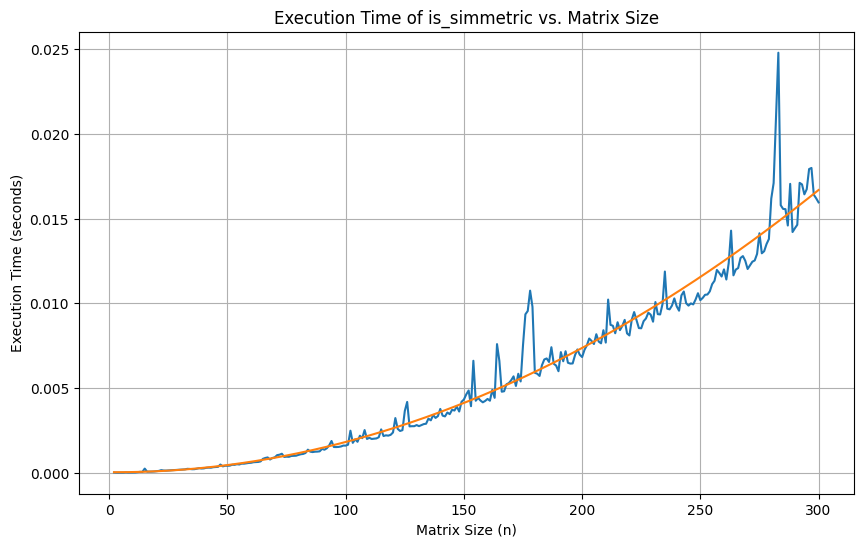

In [ ]:
# Criar o gráfico de linha
plt.figure(figsize=(10, 6))
# Original data
plt.plot(n_values, execution_times, label='Data')
# Quadratic fit
plt.plot(n_fit, time_fit, label='Quadratic Fit')

# Adicionar rótulos e título
plt.xlabel('Matrix Size (n)')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time of is_simmetric vs. Matrix Size')

# Habilitar grade
plt.grid(True)

# Exibir o gráfico
plt.show()

Questão 3

In [ ]:
import numpy as np

# Definindo a matriz Q da imagem
Q = np.array([
    [-6,  8,  4,  6],
    [ 8, -4,  8,  7],
    [ 4,  8, -10, 7],
    [ 6,  7,  7, -4]
])

# Vetores da Questão 3
x = np.array([0, 0, 1, 0])
x_prime = np.array([0, 0, 1, 1])

def calcular_qubo(vetor, matriz):
    # Realiza a operação matricial x^T * Q * x
    return vetor.T @ matriz @ vetor

# Cálculo das energias
E_x = calcular_qubo(x, Q)
E_x_prime = calcular_qubo(x_prime, Q)
delta_E = E_x_prime - E_x

print(f"Energia de x: {E_x}")
print(f"Energia de x': {E_x_prime}")
print(f"Delta E (Variação): {delta_E}")
print(f"Probabilidade: {np.exp(-delta_E / 10)}")

# Dica para a probabilidade de Metropolis:
# Se delta_E <= 0, Prob = 1.0
# Se delta_E > 0, Prob = exp(-delta_E / T)

Energia de x: -10
Energia de x': 0
Delta E (Variação): 10
Probabilidade: 0.36787944117144233


# Lista 3 - Bloco 3

Questão 1

In [ ]:
# Dados do problema
x = 2
y = 8

# Condições iniciais
w = 1
b = 2
eta = 0.25

losses = []
iteration = 0

while True:
    # Predição
    y_pred = w * x + b

    # Loss (MSE com fator 1/2)
    loss = 0.5 * (y_pred - y) ** 2

    # Arredondar para três casas decimais
    loss_rounded = round(loss, 3)
    losses.append(loss_rounded)

    # Parar quando loss < 0.1
    if loss < 0.1:
        break

    # Gradientes
    dL_dw = (y_pred - y) * x
    dL_db = (y_pred - y)

    # Atualização
    w = w - eta * dL_dw
    b = b - eta * dL_db

    iteration += 1

# Mostrar resultados
print("Losses:")
print(";".join(f"{l:.3f}" for l in losses))

print("\nValores finais:")
print(f"w = {w:.4f}")
print(f"b = {b:.4f}")

Losses:
8.000;0.500;0.031

Valores finais:
w = 2.5000
b = 2.7500


In [ ]:
import numpy as np

# -------------------------
# Função ReLU e derivada
# -------------------------
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return float(x > 0)

# -------------------------
# Dados
# -------------------------
x1, x2 = 0.4, 0.8
y = 3
eta = 0.2

# -------------------------
# Pesos iniciais
# -------------------------

# Camada oculta
w11 = 0.5
w12 = -0.2
w21 = -0.4
w22 = 0.9

b1 = 0.1
b2 = -0.3

# Camada saída
v1 = 0.7
v2 = 0.6
b3 = 0.2

results = []

# -------------------------
# Treinamento (3 iterações)
# -------------------------

for _ in range(3):

    # -------------------------
    # Forward
    # -------------------------

    z1 = w11*x1 + w12*x2 + b1
    z2 = w21*x1 + w22*x2 + b2

    h1 = relu(z1)
    h2 = relu(z2)

    z3 = v1*h1 + v2*h2 + b3
    y_pred = relu(z3)

    # Loss
    loss = 0.5*(y_pred - y)**2

    # Guardar resultado arredondado
    results.append((round(y_pred,3), round(loss,3)))

    # -------------------------
    # Backpropagation
    # -------------------------

    dL_dy = (y_pred - y)
    dy_dz3 = relu_deriv(z3)

    dL_dz3 = dL_dy * dy_dz3

    # Gradientes saída
    dL_dv1 = dL_dz3 * h1
    dL_dv2 = dL_dz3 * h2
    dL_db3 = dL_dz3

    # Gradientes camada oculta
    dL_dh1 = dL_dz3 * v1
    dL_dh2 = dL_dz3 * v2

    dh1_dz1 = relu_deriv(z1)
    dh2_dz2 = relu_deriv(z2)

    dL_dz1 = dL_dh1 * dh1_dz1
    dL_dz2 = dL_dh2 * dh2_dz2

    dL_dw11 = dL_dz1 * x1
    dL_dw12 = dL_dz1 * x2
    dL_db1  = dL_dz1

    dL_dw21 = dL_dz2 * x1
    dL_dw22 = dL_dz2 * x2
    dL_db2  = dL_dz2

    # -------------------------
    # Atualização
    # -------------------------

    w11 -= eta * dL_dw11
    w12 -= eta * dL_dw12
    b1  -= eta * dL_db1

    w21 -= eta * dL_dw21
    w22 -= eta * dL_dw22
    b2  -= eta * dL_db2

    v1 -= eta * dL_dv1
    v2 -= eta * dL_dv2
    b3 -= eta * dL_db3


# -------------------------
# Resultado final
# -------------------------

print(";".join(f"({y:.3f}; {l:.3f})" for y,l in results))

(0.454; 3.241);(1.905; 0.599);(2.951; 0.001)


Questão 8

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.6 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
from pennylane import numpy as np

In [ ]:
def questao8() -> float:
    x1 = np.pi
    x2 = - np.pi
    x3 = np.pi
    dev = qml.device('default.qubit', wires=3)

    @qml.qnode(dev)
    def circuit(x1, x2, x3):
        qml.RX(x1, wires=0)
        qml.RX(x2, wires=1)
        qml.RX(x3, wires=2)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1) @ qml.PauliZ(2))

    return float(circuit(x1, x2, x3).item())

In [ ]:
print(questao8())
type(questao8())

-1.0


float